### Imports

In [21]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

### Parameters (From Seed Paper)

In [22]:
# w1, w2, w3 are hormone removal rates
w1 = 0.17
w2 = 0.035
w3 = 0.0086
wC = np.log(2) / (7 * 24 * 60) # 7 day half life
wA = np.log(2) / (14 * 24 * 60) # 14 day half life
n  = 3 # Hill coefficient

D_stress = 30
D_stop = 120
tau      = 2000 # GR recovery constant

In [23]:
# inputs: x3 (cortisol), pGR_val  = pGR(t)
def f_hill(x3, pGR_val):
    return 1.0 / (1.0 + (x3 / pGR_val) ** n)

# dynamic GR feedback
def pGR(t):
    t_days = t / 1440
    phase = "chronic" if t_days >=D_stress else "healthy"
    # Phase: healthy
    if t_days < D_stress:
        return 5.0
    # Phase: chronic pulse input
    elif D_stress <= t_days <= D_stop:
        return 5.0
    # Phase: recovery
    else:
        # Exponential recovery from 5 back to 2
        return 2.0 + 3.0 * np.exp(-(t - D_stop*1440) / tau)

# pulse input u(t) that lasts for a few weeks, shows elevated hormones during the stress, and a return to baseline within hours after the stress is over
# baseline u = 1, then pulse input (u=4) lasting 3 months, then return to baseline (u=1)
def u(t):
    t_days = t / 1440
    phase = "chronic" if t_days >=D_stress else "healthy"
    
    if phase == "healthy":
        return 1.0 
    elif phase == "chronic":
        if t_days <= D_stop:     # Chronic Stress Phase
            return 4.0
        else:                # Recovery Phase
            return 1

In [24]:
def hpa_model(y, t):
    x1, x2, x3, C, A = y
    
    u_t = u(t)
    K_t = pGR(t)
    
    # GR feedback
    G_x3 = 1.0 / (1.0 + (x3 / K_t)**n)

    # MR feedback
    M_x3 = 1.0 / x3

    g1 = G_x3 * M_x3
    g2 = G_x3
    
    # Differential Equations
    dx1 = w1 * (u_t * g1 - x1)
    dx2 = w2 * (C * x1 * g2 - x2)
    dx3 = w3 * (A * x2 - x3)
    dC  = wC * C * (x1 - 1.0) 
    dA  = wA * A * (x2  - 1.0) 
    
    return [dx1, dx2, dx3, dC, dA]

In [25]:
t_days = 200 # timescale of 200 days
t_eval = np.linspace(0, t_days * 1440, 10000)
y0 = [1.0, 1.0, 1.0, 1.0, 1.0] # initial conditions

# Run simulations
sol = odeint(hpa_model, y0, t_eval, args=())


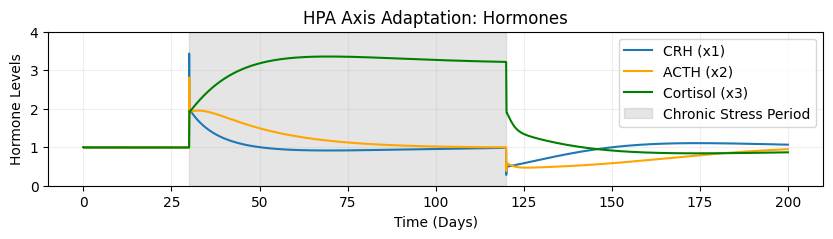

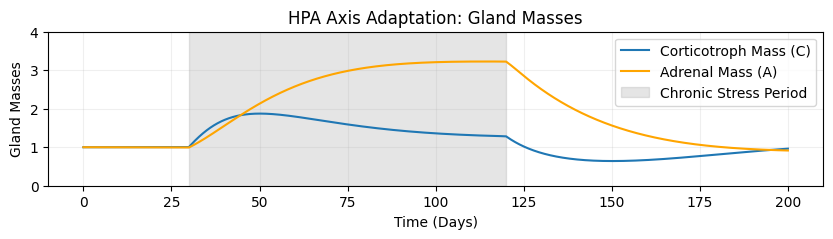

In [26]:
# plotting
plt.figure(figsize=(10, 2))
plt.plot(t_eval/1440, sol[:, 0], label='CRH (x1)', color='tab:blue')
plt.plot(t_eval/1440, sol[:, 1], label='ACTH (x2)', color='orange')
plt.plot(t_eval/1440, sol[:, 2], label='Cortisol (x3)', color='green')
plt.axvspan(D_stress, D_stop, color='gray', alpha=0.2, label='Chronic Stress Period')
plt.title("HPA Axis Adaptation: Hormones")
plt.xlabel("Time (Days)")
plt.ylabel("Hormone Levels")
plt.ylim(0, 4)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(10, 2))
plt.plot(t_eval/1440, sol[:, 3], label='Corticotroph Mass (C)', color='tab:blue')
plt.plot(t_eval/1440, sol[:, 4], label='Adrenal Mass (A)', color='orange')
plt.axvspan(D_stress, D_stop, color='gray', alpha=0.2, label='Chronic Stress Period')
plt.title("HPA Axis Adaptation: Gland Masses")
plt.xlabel("Time (Days)")
plt.ylabel("Gland Masses")
plt.legend()
plt.ylim(0, 4)
plt.grid(alpha=0.2)
plt.show()

# Novel Extension: Melatonin-Modulated GR Resistance

In [27]:
MEL_active = True 

def pGR_melatonin(t, mel_on=False):
    t_days = t / 1440
    # melatonin 'normalizes' symptoms and increases sensitivity.
    # cap the feedback degradation (K_t) during stress
    # and lower the baseline K_t (increase sensitivity) during recovery.
    
    base_K = 5.0
    stressed_K = 5.0
    recovered_K = 2.0
    
    if mel_on:
        # Melatonin increases sensitivity to feedback (lowers K_t)
        stressed_K = 3.0   # Less resistance during stress
        recovered_K = 1.0  # Higher sensitivity
        
    if t_days < D_stress:
        return base_K
    elif D_stress <= t_days <= D_stop:
        return stressed_K
    else:
        # recovery
        return recovered_K + (stressed_K - recovered_K) * np.exp(-(t - D_stop*1440) / tau)

In [28]:
def hpa_model_mel(y, t, mel_on):
    x1, x2, x3, C, A = y
    u_t = u(t)
    
    # Apply melatonin logic to the GR threshold K_t
    K_t = pGR_melatonin(t, mel_on=mel_on)
    
    # increased sensitivity to feedback
    G_x3 = 1.0 / (1.0 + (x3 / K_t)**n)
    M_x3 = 1.0 / x3
    
    dx1 = w1 * (u_t * G_x3 * M_x3 - x1)
    dx2 = w2 * (C * x1 * G_x3 - x2)
    dx3 = w3 * (A * x2 - x3)
    dC  = wC * C * (x1 - 1.0)
    dA  = wA * A * (x2 - 1.0)
    return [dx1, dx2, dx3, dC, dA]

In [29]:
t_eval = np.linspace(0, 200 * 1440, 10000)
y0 = [1.0, 1.0, 1.0, 1.0, 1.0]

sol_control = odeint(hpa_model_mel, y0, t_eval, args=(False,))
sol_mel = odeint(hpa_model_mel, y0, t_eval, args=(True,))

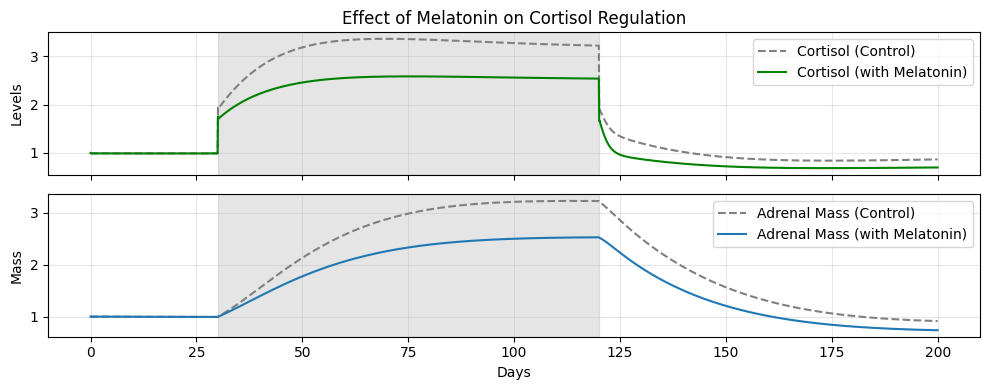

In [30]:
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

# Hormone Plot (Cortisol/x3)
ax[0].plot(t_eval/1440, sol_control[:, 2], label='Cortisol (Control)', color='gray', linestyle='--')
ax[0].plot(t_eval/1440, sol_mel[:, 2], label='Cortisol (with Melatonin)', color='green')
ax[0].set_ylabel("Levels")
ax[0].set_title("Effect of Melatonin on Cortisol Regulation")
ax[0].legend()

# Gland Mass (Adrenal/A)
ax[1].plot(t_eval/1440, sol_control[:, 4], label='Adrenal Mass (Control)', color='gray', linestyle='--')
ax[1].plot(t_eval/1440, sol_mel[:, 4], label='Adrenal Mass (with Melatonin)', color='tab:blue')
ax[1].set_ylabel("Mass")
ax[1].set_xlabel("Days")
ax[1].legend()

for a in ax:
    a.axvspan(D_stress, D_stop, color='gray', alpha=0.2, label='Stress')
    a.grid(alpha=0.3)

plt.tight_layout()
plt.show()